In [1]:
import random
import torch
from d2l import torch as d2l

In [13]:
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))  # 将y转换成列向量, pytorch对于上述乘法默认生成的是一个行向量

In [14]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

In [15]:
print('features shape:', features.shape, '\nlabel shape:', labels.shape)

features shape: torch.Size([1000, 2]) 
label shape: torch.Size([1000, 1])


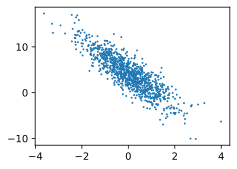

In [16]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 1)

In [17]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 随机读取样本
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [ ]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[ 0.9668, -0.1343],
        [-0.1100,  0.7766],
        [ 2.2486,  0.4476],
        [ 0.4313, -0.7672],
        [ 0.1388, -1.0796],
        [-0.2155,  0.0951],
        [-0.3482, -1.4488],
        [ 1.0527, -0.2236],
        [-1.3683, -0.0573],
        [-0.1599,  0.2180]]) 
 tensor([[6.6015],
        [1.3339],
        [7.1865],
        [7.6719],
        [8.1504],
        [3.4429],
        [8.4326],
        [7.0563],
        [1.6615],
        [3.1294]])


In [24]:
# 初始化参数
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

In [19]:
# 定义线性回归模型
def linear_reg(X, w, b):
    return torch.matmul(X, w) + b

In [20]:
# 定义MSE损失函数，注意这里没有对每个样本进行求和
def squared_loss(y_hat, y):
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [21]:
# 定义随机梯度下降函数
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [25]:
lr = 0.03
num_epochs = 3
batch_size = 10
net = linear_reg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)
        l.sum().backward()
        sgd([w, b], lr, batch_size)

    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.037680
epoch 2, loss 0.000139
epoch 3, loss 0.000052


In [26]:
print(f'w的估计误差：{true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差： {true_b - b}')

w的估计误差：tensor([1.0991e-04, 1.4305e-05], grad_fn=<SubBackward0>)
b的估计误差： tensor([0.0002], grad_fn=<RsubBackward1>)
